In [ ]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

from domain_analysis import (
    base_domain_sql,
    subdomain_sql,
    build_domain_summary,
    build_subdomain_breakdown,
)

pd.set_option('display.max_rows', 120)
pd.set_option('display.max_colwidth', 80)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

con = duckdb.connect('doi.gov/cdxj.duckdb', read_only=True)
print('Connected to doi.gov/cdxj.duckdb')

## doi.gov — Overview

In [2]:
# Total rows and captures per year
con.sql("SELECT COUNT(*) AS total_rows FROM eot_captures").show()
con.sql("""
    SELECT crawl_year, COUNT(*) AS captures
    FROM eot_captures GROUP BY 1 ORDER BY 1
""").show()

┌────────────┐
│ total_rows │
│   int64    │
├────────────┤
│    1749412 │
└────────────┘

┌────────────┬──────────┐
│ crawl_year │ captures │
│  varchar   │  int64   │
├────────────┼──────────┤
│ 2004       │    54653 │
│ 2008       │   224342 │
│ 2012       │    93012 │
│ 2016       │   131435 │
│ 2020       │  1245970 │
└────────────┴──────────┘



In [3]:
# Host × year breakdown
con.sql("""
    SELECT host, crawl_year, COUNT(*) AS n
    FROM eot_captures
    GROUP BY 1, 2
    ORDER BY n DESC
""").show(max_rows=30)

┌───────────────────────────────┬────────────┬─────────┐
│             host              │ crawl_year │    n    │
│            varchar            │  varchar   │  int64  │
├───────────────────────────────┼────────────┼─────────┤
│ data.doi.gov                  │ 2020       │ 1210710 │
│ www.doi.gov                   │ 2008       │  110747 │
│ library.doi.gov               │ 2008       │   96657 │
│ www.doi.gov                   │ 2016       │   65408 │
│ www.doi.gov                   │ 2012       │   53664 │
│ www.doi.gov                   │ 2004       │   27421 │
│ www.oha.doi.gov               │ 2016       │   27252 │
│ www.doi.gov                   │ 2020       │   17144 │
│ data.doi.gov                  │ 2016       │   14335 │
│ elips.doi.gov                 │ 2008       │   13817 │
│ igems.doi.gov                 │ 2016       │    8530 │
│ cloud.doi.gov                 │ 2016       │    8493 │
│ iosst1.ios.doi.gov            │ 2004       │    7476 │
│ elips.doi.gov                

### DomainDataSummary — high-level domain structure (SURT-derived)

In [ ]:
# Per-domain roll-up parsed from surtkey (no hardcoded host list).
# For this single-domain DB there's one row; for explore_eot.ipynb the same helper
# produces one row per target domain.
domain_summary = build_domain_summary(con)
domain_summary

In [ ]:
# Full subdomain breakdown with per-year columns
subdomain_pivot = build_subdomain_breakdown(con, limit=30)
print(f"Total unique subdomains (SURT-derived): "
      f"{con.sql(f'SELECT COUNT(DISTINCT ({subdomain_sql()})) FROM eot_captures WHERE surtkey IS NOT NULL').fetchone()[0]:,}")
subdomain_pivot

## Path Segment Analysis

In [4]:
# Position 1 strings — ranked per year
seg1 = con.sql("""
    SELECT
        COALESCE(NULLIF(path_seg_1, ''), '(root)') AS seg1,
        crawl_year,
        COUNT(*) AS n
    FROM eot_captures
    GROUP BY 1, 2
""").df()

seg1_pivot = seg1.pivot(index='seg1', columns='crawl_year', values='n').fillna(0).astype(int)
seg1_pivot['total'] = seg1_pivot.sum(axis=1)
seg1_pivot = seg1_pivot.sort_values('total', ascending=False)
seg1_pivot.head(50)

crawl_year,2004,2008,2012,2016,2020,total
seg1,,,,,,
dataset,0,0,0,13308,1197588,1210896
uhtbin,17,93837,5202,63,4,99123
sites,0,0,0,35567,13135,48702
news,3164,13432,7498,1818,361,26273
IBLA,0,0,2837,20578,5,23420
photos,449,15862,24,24,3,16362
cgi-bin,2573,7959,2330,2,0,12864
ocio,2391,8774,745,687,6,12603
calendar.cfm,0,0,12437,0,0,12437


In [5]:
# Position 2 strings — ranked per year
seg2 = con.sql("""
    SELECT
        COALESCE(NULLIF(path_seg_1, ''), '(root)') AS seg1,
        COALESCE(NULLIF(path_seg_2, ''), '(none)') AS seg2,
        crawl_year,
        COUNT(*) AS n
    FROM eot_captures
    GROUP BY 1, 2, 3
""").df()

seg2_pivot = seg2.pivot_table(index=['seg1', 'seg2'], columns='crawl_year', values='n',
                              aggfunc='sum').fillna(0).astype(int)
seg2_pivot['total'] = seg2_pivot.sum(axis=1)
seg2_pivot = seg2_pivot.sort_values('total', ascending=False)
seg2_pivot.head(50)

,crawl_year,2004,2008,2012,2016,2020,total
seg1,seg2,,,,,,
dataset,(none),0,0,0,7707,1157129,1164836
uhtbin,cgisirsi,16,93834,5200,38,2,99090
sites,doi.gov,0,0,0,32063,10224,42287
IBLA,Ibladecisions,0,0,2786,20406,5,23197
calendar.cfm,(none),0,0,12437,0,0,12437
photos,kempthorne,0,11866,10,2,0,11878
harvest,object,0,0,0,414,9438,9852
arcgis,rest,0,0,0,8162,56,8218
cgi-bin,intercept,2548,4393,1169,2,0,8112


In [6]:
# Position 3 strings — ranked per year
seg3 = con.sql("""
    SELECT
        COALESCE(NULLIF(path_seg_1, ''), '(root)') AS seg1,
        COALESCE(NULLIF(path_seg_2, ''), '(none)') AS seg2,
        COALESCE(NULLIF(path_seg_3, ''), '(none)') AS seg3,
        crawl_year,
        COUNT(*) AS n
    FROM eot_captures
    GROUP BY 1, 2, 3, 4
""").df()

seg3_pivot = seg3.pivot_table(index=['seg1', 'seg2', 'seg3'], columns='crawl_year', values='n',
                              aggfunc='sum').fillna(0).astype(int)
seg3_pivot['total'] = seg3_pivot.sum(axis=1)
seg3_pivot = seg3_pivot.sort_values('total', ascending=False)
seg3_pivot.head(50)

,,crawl_year,2004,2008,2012,2016,2020,total
seg1,seg2,seg3,,,,,,
dataset,(none),(none),0,0,0,7707,1157129,1164836
sites,doi.gov,files,0,0,0,32042,10210,42252
calendar.cfm,(none),(none),0,0,12437,0,0,12437
arcgis,rest,services,0,0,0,8106,54,8160
cgi-bin,intercept,(none),2548,4393,1169,2,0,8112
ost,PDFs,PDFS,0,0,5220,10,0,5230
robots.txt,(none),(none),248,315,378,687,3566,5194
cgi-bin,%22http:,(none),0,3550,1154,0,0,4704
stconf.nsf,vwCalendar,(none),3579,0,0,0,0,3579


In [7]:
# Position 4 strings — ranked per year
seg4 = con.sql("""
    SELECT
        COALESCE(NULLIF(path_seg_1, ''), '(root)') AS seg1,
        COALESCE(NULLIF(path_seg_2, ''), '(none)') AS seg2,
        COALESCE(NULLIF(path_seg_3, ''), '(none)') AS seg3,
        COALESCE(NULLIF(path_seg_4, ''), '(none)') AS seg4,
        crawl_year,
        COUNT(*) AS n
    FROM eot_captures
    GROUP BY 1, 2, 3, 4, 5
""").df()

seg4_pivot = seg4.pivot_table(index=['seg1', 'seg2', 'seg3', 'seg4'], columns='crawl_year', values='n',
                              aggfunc='sum').fillna(0).astype(int)
seg4_pivot['total'] = seg4_pivot.sum(axis=1)
seg4_pivot = seg4_pivot.sort_values('total', ascending=False)
seg4_pivot.head(50)

crawl_year                                                                                              2004  \
seg1             seg2                                 seg3                          seg4                       
dataset          (none)                               (none)                        (none)                 0   
sites            doi.gov                              files                         migrated               0   
calendar.cfm     (none)                               (none)                        (none)                 0   
cgi-bin          intercept                            (none)                        (none)              2548   
sites            doi.gov                              files                         css                    0   
robots.txt       (none)                               (none)                        (none)               248   
sites            doi.gov                              files                         uploads                0   
                                                                                    styles                 0   
stconf.nsf       vwCalendar                           (none)                        (none)              3579   
arcgis           rest                                 services                      globalelus             0   
blmevents.nsf    f3cf399b700e3d5c8825698a006b95e7     (none)                        (none)              2893   
stconf.nsf       2e9edf44ebaed33d8525668f005779d2     (none)                        (none)              2814   
app_dm           dsp_description.cfm                  (none)                        (none)               903   
sites            doi.opengov.ibmcloud.com             themes                        custom                 0   
app_dm           act_getfiles.cfm                     (none)                        (none)               749   
adfs             ls                                   (none)                        (none)                 0   
organization     af69efa6-baa3-454a-9e8e-2d417aa0cc00 (none)                        (none)                 0   
app_DM           dsp_description.cfm                  (none)                        (none)               971   
sites            doi.opengov.ibmcloud.com             files                         uploads                0   
app_DM           act_getfiles.cfm                     (none)                        (none)               750   
ocio             privacy                              Privacy%20Notices%20for%20DOI Interior%20Notices   429   
doi              CSS                                  CSS                           jScript                0   
restoration      library                              casedocs                      upload                 0   
sites            doi.gov                              files                         js                     0   
                                                                                    archive                0   
subsistence      library                              transcripts                   upload                 0   
bia              docs                                 ofa                           adc                    0   
doi              jScript                              jScript                       CSS                    0   
                 CSS                                  jScript                       CSS                    0   
ocio             architecture                         tutorial                      images               198   
oia              press                                2007                          photos                 0   
doi              jScript                              CSS                           jScript                0   
ocio             architecture                         documents                     metamodel            539   
whatwedo         climate                              strategy                  

In [8]:
# Position 5 strings — ranked per year
seg5 = con.sql("""
    SELECT
        COALESCE(NULLIF(path_seg_1, ''), '(root)') AS seg1,
        COALESCE(NULLIF(path_seg_2, ''), '(none)') AS seg2,
        COALESCE(NULLIF(path_seg_3, ''), '(none)') AS seg3,
        COALESCE(NULLIF(path_seg_4, ''), '(none)') AS seg4,
        COALESCE(NULLIF(path_seg_5, ''), '(none)') AS seg5,
        crawl_year,
        COUNT(*) AS n
    FROM eot_captures
    GROUP BY 1, 2, 3, 4, 5, 6
""").df()

seg5_pivot = seg5.pivot_table(index=['seg1', 'seg2', 'seg3', 'seg4', 'seg5'], columns='crawl_year', values='n',
                              aggfunc='sum').fillna(0).astype(int)
seg5_pivot['total'] = seg5_pivot.sum(axis=1)
seg5_pivot = seg5_pivot.sort_values('total', ascending=False)
seg5_pivot.head(50)

,,,,crawl_year,2004,2008,2012,2016,2020,total
seg1,seg2,seg3,seg4,seg5,,,,,,
dataset,(none),(none),(none),(none),0,0,0,7707,1157129,1164836
calendar.cfm,(none),(none),(none),(none),0,0,12437,0,0,12437
cgi-bin,intercept,(none),(none),(none),2548,4393,1169,2,0,8112
robots.txt,(none),(none),(none),(none),248,315,378,687,3566,5194
stconf.nsf,vwCalendar,(none),(none),(none),3579,0,0,0,0,3579
arcgis,rest,services,globalelus,MapServer,0,0,0,3404,0,3404
sites,doi.gov,files,migrated,subsistence,0,0,0,3080,0,3080
blmevents.nsf,f3cf399b700e3d5c8825698a006b95e7,(none),(none),(none),2893,0,0,0,0,2893
stconf.nsf,2e9edf44ebaed33d8525668f005779d2,(none),(none),(none),2814,0,0,0,0,2814


### File Extensions — doi.gov

In [9]:
# File extensions — ranked per year
ext_df = con.sql("""
    SELECT
        COALESCE(NULLIF(lower(regexp_extract(url_path, '\\.([a-zA-Z0-9]+)$', 1)), ''), '(none)') AS ext,
        crawl_year,
        COUNT(*) AS n
    FROM eot_captures
    GROUP BY 1, 2
""").df()

ext_pivot = ext_df.pivot(index='ext', columns='crawl_year', values='n').fillna(0).astype(int)
ext_pivot['total'] = ext_pivot.sum(axis=1)
ext_pivot = ext_pivot.sort_values('total', ascending=False)
ext_pivot

crawl_year,2004,2008,2012,2016,2020,total
ext,,,,,,
(none),13622,104206,12776,24879,1213033,1368516
pdf,4495,14383,20633,80886,661,121058
jpg,3840,29430,10572,3294,3266,50402
cfm,4842,5536,30706,1065,116,42265
html,7545,20363,5837,6176,583,40504
...,...,...,...,...,...,...
createelement,0,0,0,0,1,1
create,0,0,0,0,1,1
countifs,0,0,0,0,1,1


In [26]:
ext_pivot.head(50)

crawl_year,2004,2008,2012,2016,2020,total
ext,,,,,,
(none),13622,104206,12776,24879,1213033,1368516
pdf,4495,14383,20633,80886,661,121058
jpg,3840,29430,10572,3294,3266,50402
cfm,4842,5536,30706,1065,116,42265
html,7545,20363,5837,6176,583,40504
htm,7100,16829,2141,258,427,26755
gif,7255,15199,2605,507,218,25784
rdf,0,0,0,2261,8035,10296
css,161,1173,539,1141,6033,9047


### Filenames — doi.gov

In [10]:
# Filenames — ranked per year
fname_df = con.sql("""
    SELECT
        COALESCE(NULLIF(regexp_extract(url_path, '/([^/]+)$', 1), ''), '(root)') AS filename,
        crawl_year,
        COUNT(*) AS n
    FROM eot_captures
    GROUP BY 1, 2
""").df()

fname_pivot = fname_df.pivot(index='filename', columns='crawl_year', values='n').fillna(0).astype(int)
fname_pivot['total'] = fname_pivot.sum(axis=1)
fname_pivot = fname_pivot.sort_values('total', ascending=False)
fname_pivot

crawl_year,2004,2008,2012,2016,2020,total
filename,,,,,,
dataset,0,0,0,7707,1157129,1164836
49,2,48699,1713,0,0,50414
X,8,40372,2616,0,1,42997
calendar.cfm,0,0,12444,0,0,12444
(root),228,931,3964,719,2564,8406
...,...,...,...,...,...,...
12a2c8ee-445b-4bd4-8390-a25b1e97d447.rdf,0,0,0,1,0,1
12a73bd2-787b-4d47-b94b-7e58f629d197.rdf,0,0,0,0,1,1
12a83bf,0,0,0,1,0,1


In [27]:
fname_pivot.head(50)

crawl_year,2004,2008,2012,2016,2020,total
filename,,,,,,
dataset,0,0,0,7707,1157129,1164836
49,2,48699,1713,0,0,50414
X,8,40372,2616,0,1,42997
calendar.cfm,0,0,12444,0,0,12444
(root),228,931,3964,719,2564,8406
intercept,2548,4397,1169,2,0,8116
robots.txt,248,315,378,687,3566,5194
21,0,4459,533,15,0,5007
dsp_description.cfm,2216,2646,0,0,0,4862


## Visualizations

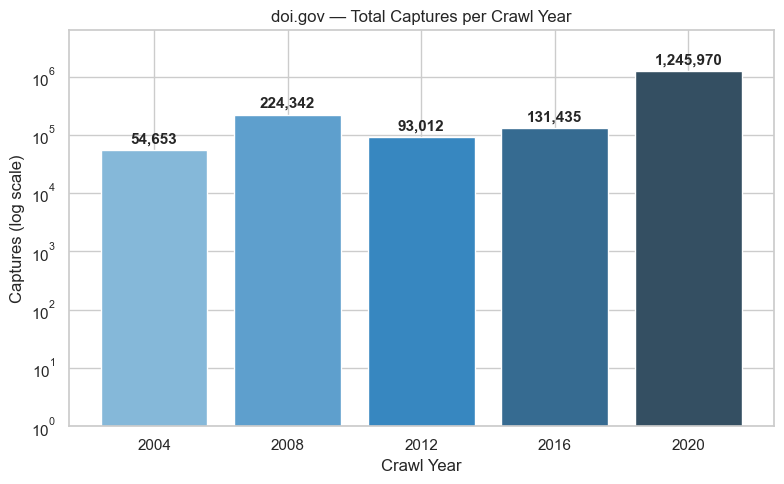

In [11]:
# Viz 1: Captures over time (bar chart, log scale)
year_counts = con.sql("""
    SELECT crawl_year, COUNT(*) AS captures
    FROM eot_captures GROUP BY 1 ORDER BY 1
""").df()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(year_counts['crawl_year'], year_counts['captures'],
              color=sns.color_palette('Blues_d', len(year_counts)))
ax.set_yscale('log')
ax.set_ylabel('Captures (log scale)')
ax.set_xlabel('Crawl Year')
ax.set_title('doi.gov — Total Captures per Crawl Year')

for bar, val in zip(bars, year_counts['captures']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.15,
            f'{val:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylim(1, year_counts['captures'].max() * 5)
plt.tight_layout()
plt.show()

In [ ]:
# Viz 2: Subdomain stacked bar — SURT-derived, no hardcoded host list
SUBDOM = subdomain_sql()
host_year = con.sql(f"""
    SELECT
        CASE WHEN {SUBDOM} = '' THEN '(bare)' ELSE {SUBDOM} END AS subdomain,
        crawl_year,
        COUNT(*) AS n
    FROM eot_captures
    WHERE surtkey IS NOT NULL
    GROUP BY 1, 2
""").df()

# Keep top 8 subdomains by total captures; bucket the long tail into 'other'
totals = host_year.groupby('subdomain')['n'].sum().sort_values(ascending=False)
top_subs = totals.head(8).index.tolist()
host_year['subdomain'] = host_year['subdomain'].where(
    host_year['subdomain'].isin(top_subs), 'other'
)

host_pivot = (host_year.pivot_table(index='crawl_year', columns='subdomain',
                                     values='n', aggfunc='sum')
                       .fillna(0).astype(int))
# Preserve rank order; push 'other' to the end if present
col_order = [s for s in top_subs if s in host_pivot.columns]
if 'other' in host_pivot.columns:
    col_order.append('other')
host_pivot = host_pivot[col_order]

ax = host_pivot.plot(kind='bar', stacked=True, figsize=(10, 6),
                     color=sns.color_palette('Set2', len(col_order)))
ax.set_ylabel('Captures')
ax.set_xlabel('Crawl Year')
ax.set_title('doi.gov — Subdomain Breakdown per Crawl Year (SURT-parsed)')
ax.legend(title='Subdomain', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

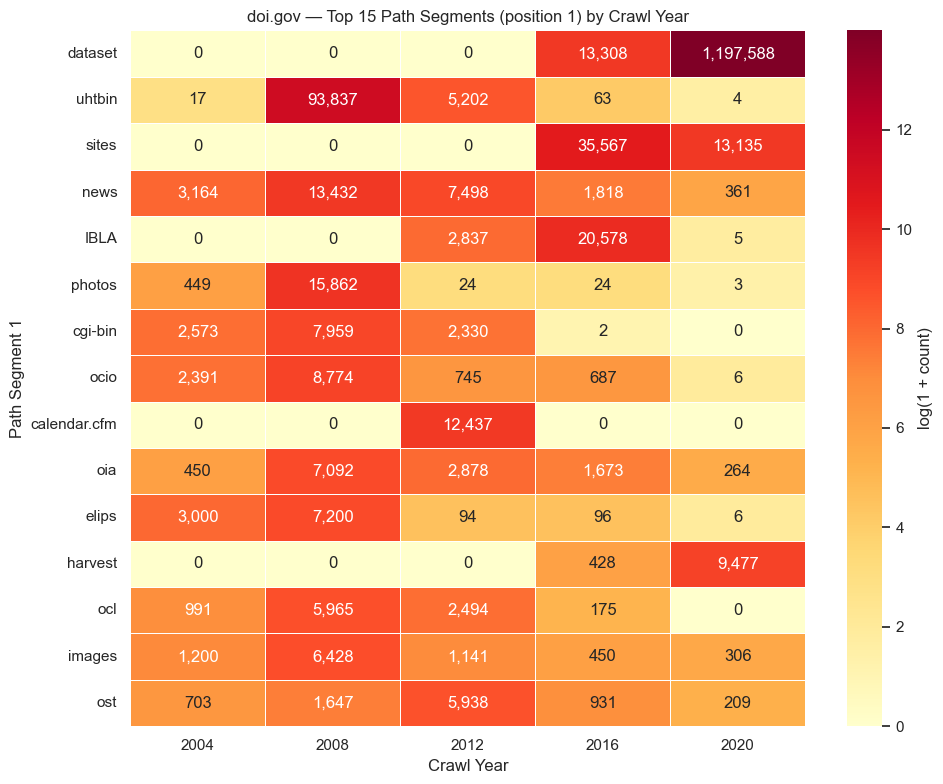

In [13]:
# Viz 3: Top 15 seg1 heatmap
top15 = seg1_pivot[seg1_pivot.index != '(root)'].head(15)
year_cols = [c for c in top15.columns if c != 'total']

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(np.log1p(top15[year_cols]), annot=top15[year_cols].values,
            fmt=',d', cmap='YlOrRd', linewidths=0.5, ax=ax,
            cbar_kws={'label': 'log(1 + count)'})
ax.set_title('doi.gov — Top 15 Path Segments (position 1) by Crawl Year')
ax.set_ylabel('Path Segment 1')
ax.set_xlabel('Crawl Year')
plt.tight_layout()
plt.show()

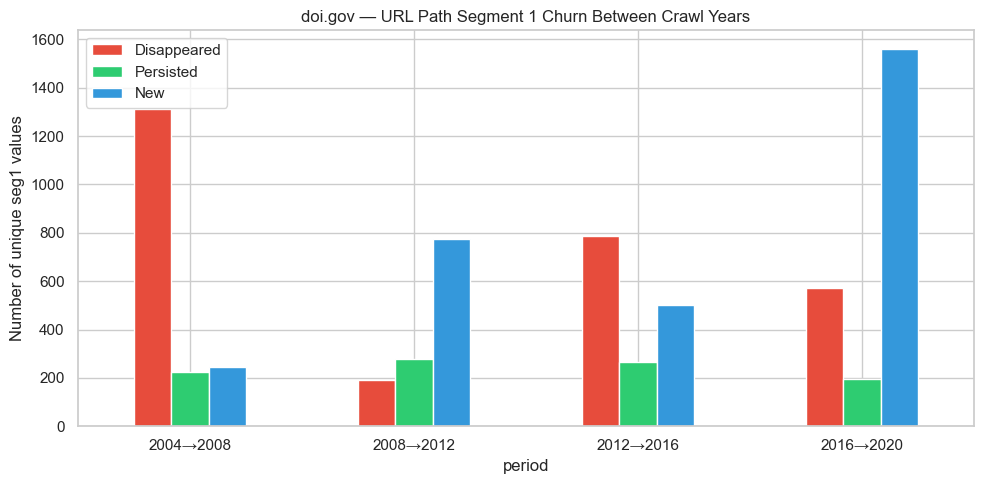

           Disappeared  Persisted   New
period                                 
2004→2008         1311        224   245
2008→2012          190        279   775
2012→2016          788        266   501
2016→2020          572        195  1559


In [14]:
# Viz 4: Seg1 churn across all adjacent crawl year pairs
years = sorted(seg1_pivot.columns[seg1_pivot.columns != 'total'])
churn_rows = []
for y1, y2 in zip(years[:-1], years[1:]):
    in_y1 = set(seg1_pivot[seg1_pivot[y1] > 0].index)
    in_y2 = set(seg1_pivot[seg1_pivot[y2] > 0].index)
    churn_rows.append({
        'period': f'{y1}→{y2}',
        'Disappeared': len(in_y1 - in_y2),
        'Persisted': len(in_y1 & in_y2),
        'New': len(in_y2 - in_y1)
    })

churn_df = pd.DataFrame(churn_rows).set_index('period')
ax = churn_df.plot(kind='bar', figsize=(10, 5),
                   color=['#e74c3c', '#2ecc71', '#3498db'])
ax.set_ylabel('Number of unique seg1 values')
ax.set_title('doi.gov — URL Path Segment 1 Churn Between Crawl Years')
ax.legend(title='')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print(churn_df.to_string())

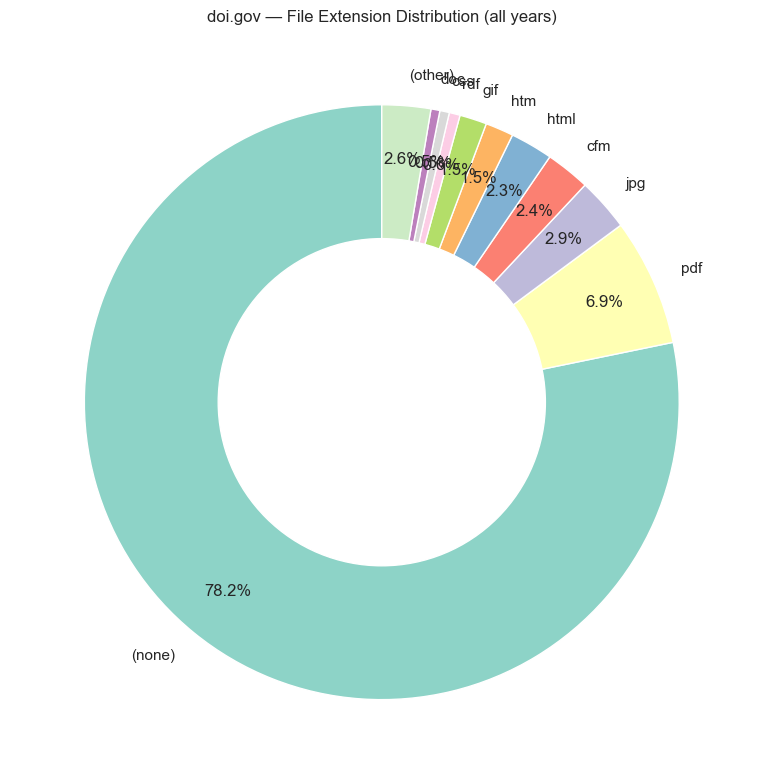

In [15]:
# Viz 5: Extension donut chart — top 10 + other
top_ext = ext_pivot.head(10).copy()
other_total = ext_pivot.iloc[10:]['total'].sum()
other_row = pd.DataFrame({'total': [other_total]}, index=['(other)'])
donut_data = pd.concat([top_ext[['total']], other_row])

fig, ax = plt.subplots(figsize=(8, 8))
colors = sns.color_palette('Set3', len(donut_data))
wedges, texts, autotexts = ax.pie(
    donut_data['total'], labels=donut_data.index, autopct='%1.1f%%',
    colors=colors, pctdistance=0.82, startangle=90)
centre = plt.Circle((0, 0), 0.55, fc='white')
ax.add_patch(centre)
ax.set_title('doi.gov — File Extension Distribution (all years)')
plt.tight_layout()
plt.show()

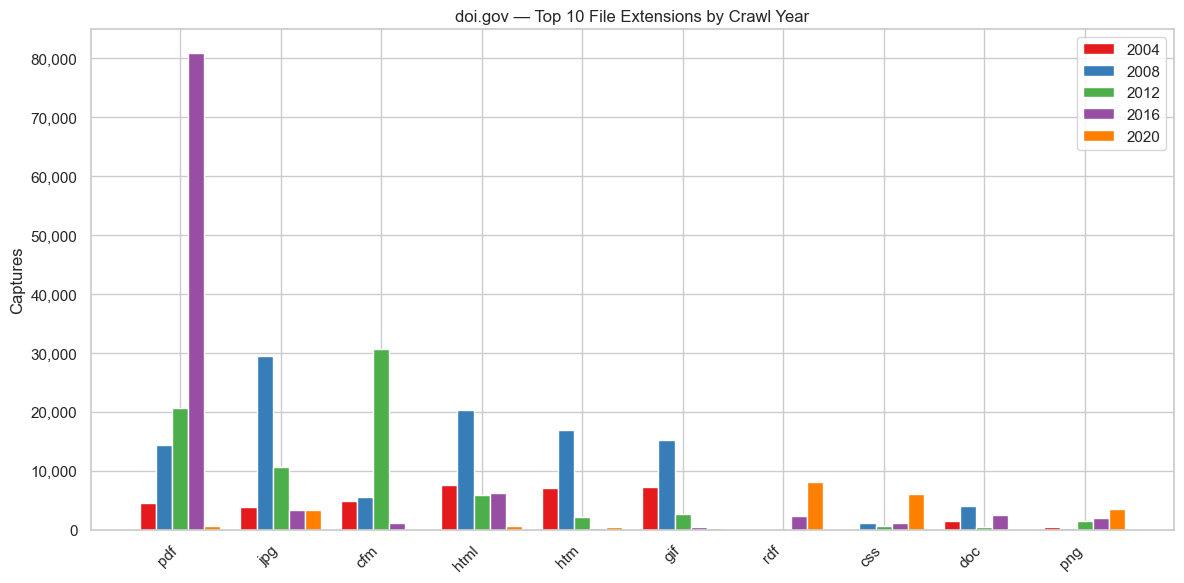

In [16]:
# Viz 6: Extension shift across years (excluding (none))
ext_no_none = ext_pivot[ext_pivot.index != '(none)'].head(10)
year_cols = [c for c in ext_no_none.columns if c != 'total']

x = np.arange(len(ext_no_none))
n_years = len(year_cols)
width = 0.8 / n_years

fig, ax = plt.subplots(figsize=(12, 6))
colors = sns.color_palette('Set1', n_years)
for i, yr in enumerate(year_cols):
    ax.bar(x + i * width - 0.4 + width/2, ext_no_none[yr], width,
           label=yr, color=colors[i])

ax.set_xticks(x)
ax.set_xticklabels(ext_no_none.index, rotation=45, ha='right')
ax.set_ylabel('Captures')
ax.set_title('doi.gov — Top 10 File Extensions by Crawl Year')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

### Treemaps

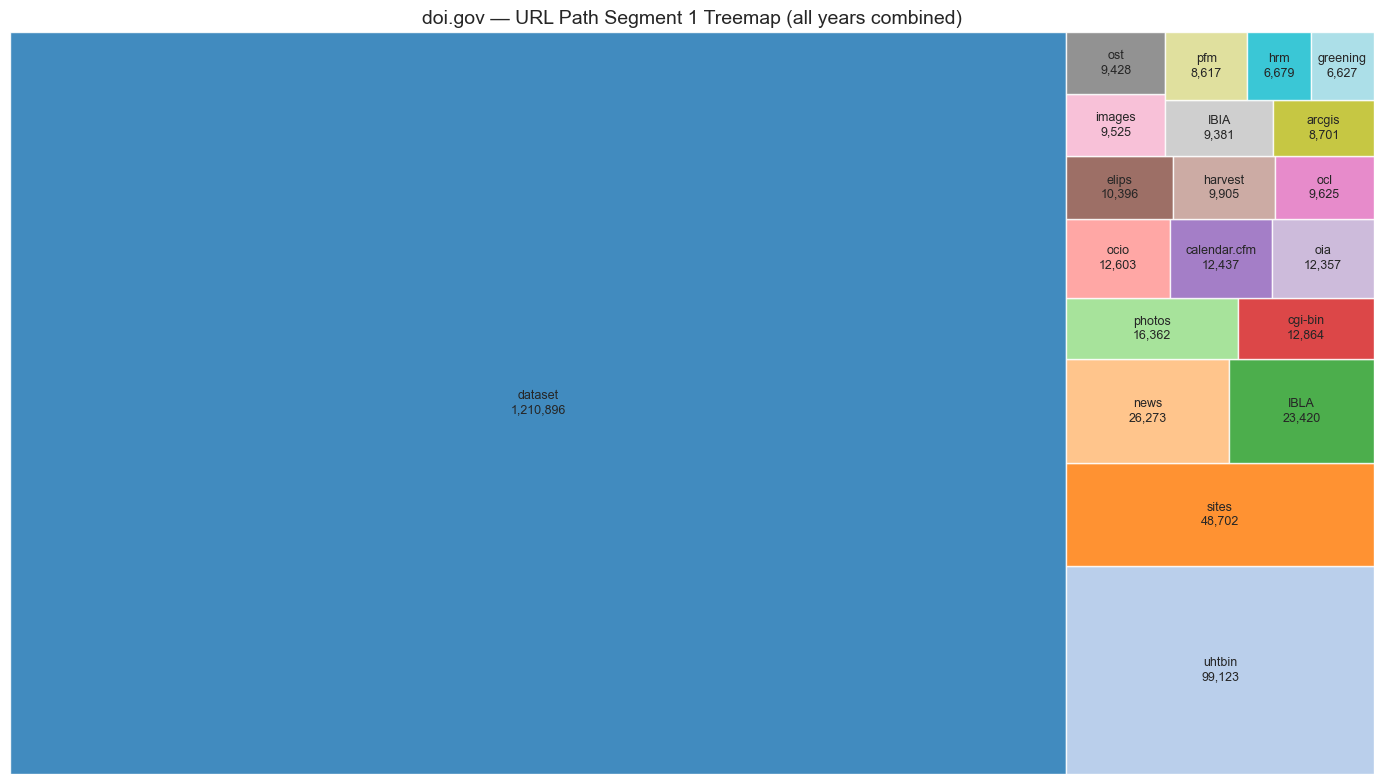

In [17]:
# Viz 7: Path hierarchy treemap — ALL years combined
try:
    import squarify
except ImportError:
    print("squarify not installed — run: pip install squarify")
    squarify = None

if squarify:
    tree_data = seg1_pivot[seg1_pivot.index != '(root)'].head(20).copy()
    labels = [f"{name}\n{total:,}" for name, total in zip(tree_data.index, tree_data['total'])]

    fig, ax = plt.subplots(figsize=(14, 8))
    colors = sns.color_palette('tab20', len(tree_data))
    squarify.plot(sizes=tree_data['total'], label=labels, color=colors, alpha=0.85,
                  text_kwargs={'fontsize': 9}, ax=ax)
    ax.set_title('doi.gov — URL Path Segment 1 Treemap (all years combined)', fontsize=14)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

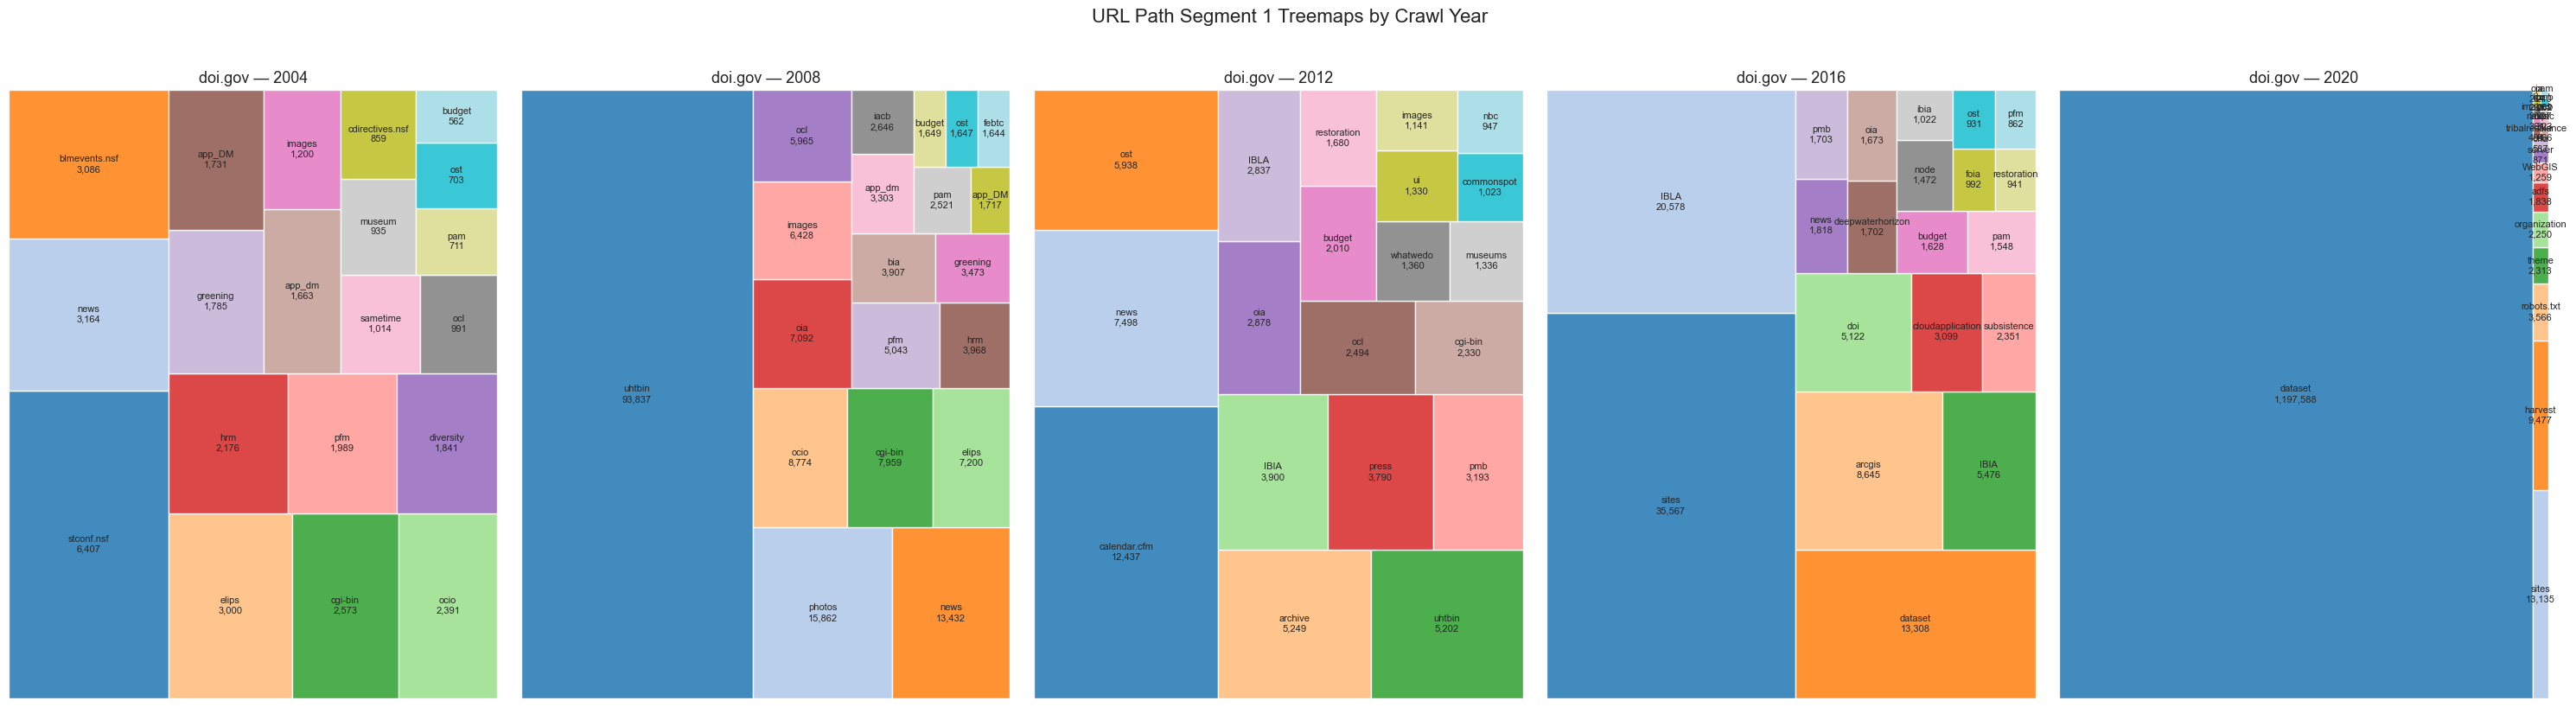

In [18]:
# Viz 7b: Treemap SEPARATED BY YEAR
try:
    import squarify
except ImportError:
    squarify = None

if squarify:
    year_cols = [c for c in seg1_pivot.columns if c != 'total']
    fig, axes = plt.subplots(1, len(year_cols), figsize=(6 * len(year_cols), 8))
    if len(year_cols) == 1:
        axes = [axes]

    for ax, yr in zip(axes, year_cols):
        yr_data = seg1_pivot[seg1_pivot[yr] > 0][[yr]].sort_values(yr, ascending=False).head(20)
        if yr_data.empty:
            ax.set_title(f'{yr} (no data)')
            ax.axis('off')
            continue

        labels = [f"{name}\n{val:,}" for name, val in zip(yr_data.index, yr_data[yr])]
        colors = sns.color_palette('tab20', len(yr_data))
        squarify.plot(sizes=yr_data[yr].values, label=labels, color=colors,
                      alpha=0.85, text_kwargs={'fontsize': 8}, ax=ax)
        ax.set_title(f'doi.gov — {yr}', fontsize=13)
        ax.axis('off')

    plt.suptitle('URL Path Segment 1 Treemaps by Crawl Year', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("squarify not installed — run: pip install squarify")

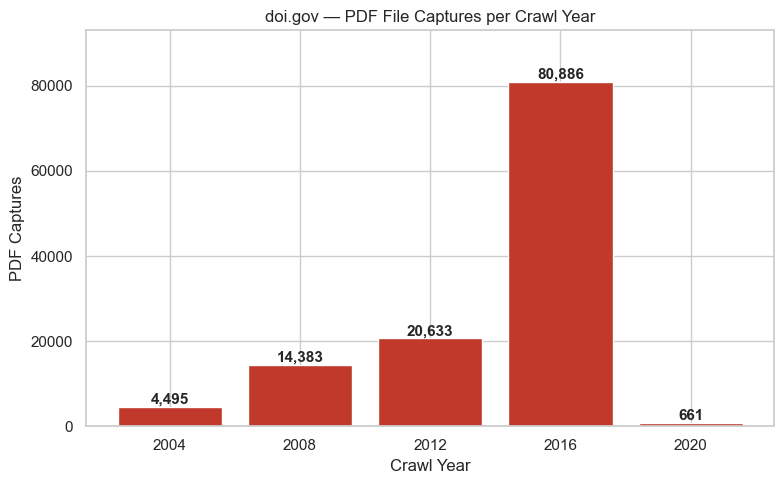

In [19]:
# Viz 8: PDF captures over time
if 'pdf' in ext_pivot.index:
    pdf_row = ext_pivot.loc['pdf']
    year_cols = [c for c in ext_pivot.columns if c != 'total']
    pdf_by_year = pdf_row[year_cols]

    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(pdf_by_year.index, pdf_by_year.values, color='#c0392b')
    for bar, val in zip(bars, pdf_by_year.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f'{val:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax.set_ylabel('PDF Captures')
    ax.set_xlabel('Crawl Year')
    ax.set_title('doi.gov — PDF File Captures per Crawl Year')
    ax.set_ylim(0, pdf_by_year.max() * 1.15)
    plt.tight_layout()
    plt.show()
else:
    print("No 'pdf' extension found.")

## Content Analysis

URL path depth statistics per crawl year:
crawl_year       n  avg_depth  median_depth  max_depth
      2004   54615   2.657676           2.0         10
      2008  224229   4.840047           5.0         14
      2012   92952   3.369191           4.0         12
      2016  131328   5.186274           4.0         17
      2020 1245826   1.188343           1.0         40


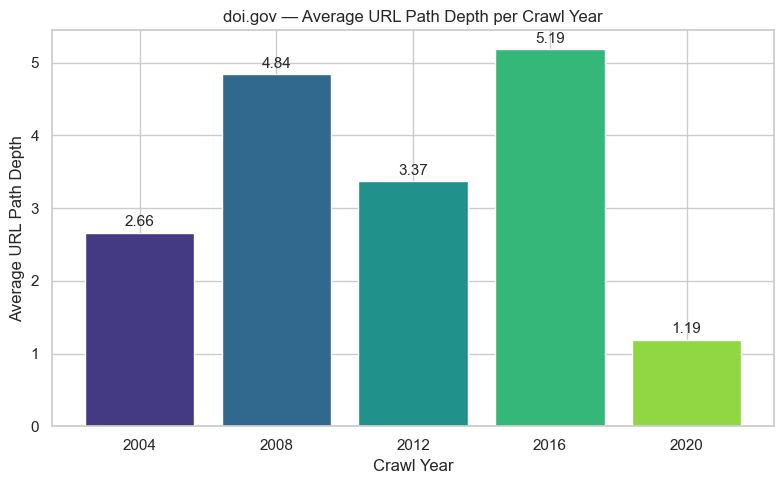

In [20]:
# Analysis 1: Average URL depth per crawl year
depth_stats = con.sql("""
    SELECT
        crawl_year,
        COUNT(*) AS n,
        AVG(len(string_split(trim(url_path, '/'), '/'))) AS avg_depth,
        MEDIAN(len(string_split(trim(url_path, '/'), '/'))) AS median_depth,
        MAX(len(string_split(trim(url_path, '/'), '/'))) AS max_depth
    FROM eot_captures
    WHERE url_path IS NOT NULL AND url_path != '' AND url_path != '/'
    GROUP BY 1 ORDER BY 1
""").df()

print("URL path depth statistics per crawl year:")
print(depth_stats.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(depth_stats['crawl_year'], depth_stats['avg_depth'],
              color=sns.color_palette('viridis', len(depth_stats)))
for bar, val in zip(bars, depth_stats['avg_depth']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.2f}', ha='center', va='bottom', fontsize=11)
ax.set_ylabel('Average URL Path Depth')
ax.set_xlabel('Crawl Year')
ax.set_title('doi.gov — Average URL Path Depth per Crawl Year')
plt.tight_layout()
plt.show()

Clean URLs (no extension) vs static files:
crawl_year  clean_urls  static_files   total  clean_pct
      2004     13622.0       41031.0   54653       24.9
      2008    104206.0      120136.0  224342       46.4
      2012     12776.0       80236.0   93012       13.7
      2016     24879.0      106556.0  131435       18.9
      2020   1213033.0       32937.0 1245970       97.4


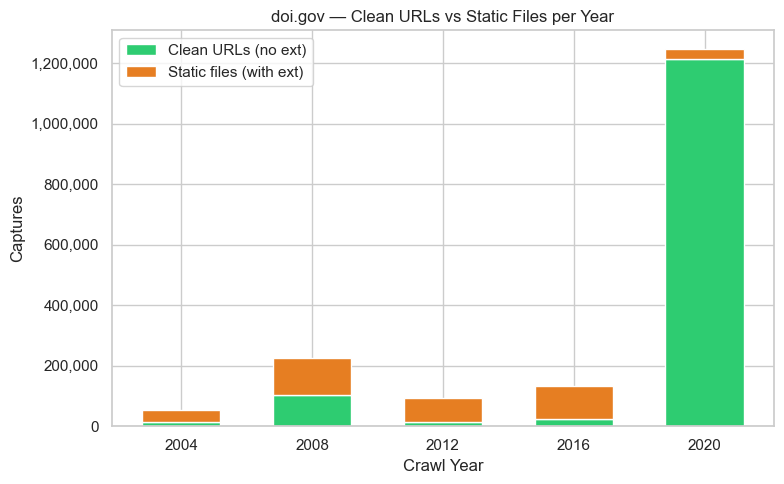

In [21]:
# Analysis 2: Clean URLs (no extension) vs static files per year
clean_vs_static = con.sql("""
    SELECT
        crawl_year,
        SUM(CASE WHEN regexp_extract(url_path, '\\.([a-zA-Z0-9]+)$', 1) = '' THEN 1 ELSE 0 END) AS clean_urls,
        SUM(CASE WHEN regexp_extract(url_path, '\\.([a-zA-Z0-9]+)$', 1) != '' THEN 1 ELSE 0 END) AS static_files,
        COUNT(*) AS total
    FROM eot_captures
    GROUP BY 1 ORDER BY 1
""").df()

clean_vs_static['clean_pct'] = (clean_vs_static['clean_urls'] / clean_vs_static['total'] * 100).round(1)
print("Clean URLs (no extension) vs static files:")
print(clean_vs_static.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(clean_vs_static))
width = 0.6
ax.bar(x, clean_vs_static['clean_urls'], width, label='Clean URLs (no ext)', color='#2ecc71')
ax.bar(x, clean_vs_static['static_files'], width, bottom=clean_vs_static['clean_urls'],
       label='Static files (with ext)', color='#e67e22')
ax.set_xticks(x)
ax.set_xticklabels(clean_vs_static['crawl_year'])
ax.set_ylabel('Captures')
ax.set_xlabel('Crawl Year')
ax.set_title('doi.gov — Clean URLs vs Static Files per Year')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

In [22]:
# Analysis 3: Top 30 PDF filenames
pdf_files = con.sql("""
    SELECT
        regexp_extract(url_path, '/([^/]+\\.pdf)$', 1) AS pdf_name,
        crawl_year,
        COUNT(*) AS n
    FROM eot_captures
    WHERE lower(regexp_extract(url_path, '\\.([a-zA-Z0-9]+)$', 1)) = 'pdf'
    GROUP BY 1, 2
""").df()

pdf_pivot = pdf_files.pivot_table(index='pdf_name', columns='crawl_year', values='n',
                                   aggfunc='sum').fillna(0).astype(int)
pdf_pivot['total'] = pdf_pivot.sum(axis=1)
pdf_pivot = pdf_pivot.sort_values('total', ascending=False)

print(f"Total unique PDF filenames: {len(pdf_pivot):,}")
pdf_pivot.head(30)

Total unique PDF filenames: 48,414


crawl_year,2004,2008,2012,2016,2020,total
pdf_name,,,,,,
,50,136,2992,4505,1,7684
foreword.pdf,8,28,26,16,0,78
overview.pdf,6,22,26,21,0,75
entire.pdf,11,30,0,2,0,43
A001.pdf,5,17,2,18,0,42
F001.pdf,5,17,2,17,0,41
E001.pdf,5,17,2,14,0,38
J001.pdf,5,17,2,14,0,38
C001.pdf,5,17,2,13,0,37


### CDX MIME type vs File Extension

In [23]:
# Analysis 4: Compare CDX 'mime' field with file extension
mime_vs_ext = con.sql("""
    SELECT
        mime,
        COALESCE(NULLIF(lower(regexp_extract(url_path, '\\.([a-zA-Z0-9]+)$', 1)), ''), '(none)') AS ext,
        COUNT(*) AS n
    FROM eot_captures
    GROUP BY 1, 2
    ORDER BY n DESC
""").df()

print(f"Unique mime×ext combinations: {len(mime_vs_ext):,}")
print("\nTop 30 mime × extension combinations:")
mime_vs_ext.head(30)

Unique mime×ext combinations: 1,052

Top 30 mime × extension combinations:


,mime,ext,n
0,text/html,(none),1356215
1,application/pdf,pdf,83545
2,image/jpeg,jpg,47835
3,text/html,cfm,40953
4,text/html,html,40310
5,text/html,pdf,28774
6,text/html,htm,26590
7,image/gif,gif,23707
8,NaN,pdf,8702
9,image/png,(none),7166


### Export all tables as CSVs

In [24]:
# Save all doi.gov pivot tables as CSVs
# tables = {
#     'doi_seg1': seg1_pivot,
#     'doi_seg2': seg2_pivot,
#     'doi_seg3': seg3_pivot,
#     'doi_seg4': seg4_pivot,
#     'doi_seg5': seg5_pivot,
#     'doi_extensions': ext_pivot,
#     'doi_filenames': fname_pivot,
# }
#
# for name, df in tables.items():
#     path = f'{name}.csv'
#     df.to_csv(path)
#     print(f'  {path} — {len(df):,} rows')

In [25]:
con.close()